In [104]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import unicodedata
import matplotlib.font_manager as fm
import matplotlib.patheffects as path_effects
import datetime
import time

In [105]:
#한글 폰트 설정
font_path = 'NotoSansKR-Regular.ttf'
fontprop = fm.FontProperties(fname=font_path)
plt.rc('font', family=fontprop.get_name())

In [106]:
#데이터 경로 설정
base_folder = '/Users/limtae-kyu/data-analysis'
folders = ['광야', '돌산', '돔구장', '돔자연짬', '말미잘', '오아시스', '옹기종기', '유적지', '철탑', '터널']

In [107]:
#데이터 불러오기
all_data = []
max_depths = []
diving_times = []
for folder in folders:
    folder_path = os.path.join(base_folder, folder)
    if os.path.isdir(folder_path):
        for filename in os.listdir(folder_path):
            if filename.endswith('.csv'):
                file_path = os.path.join(folder_path, filename)

                # 첫 두 행을 별도로 읽기
                with open(file_path, 'r') as file:
                    first_two_lines = [file.readline().strip() for _ in range(2)]
                    #print(f"{filename} 설명 행: {first_two_lines}")
                    # Start Date 찾기: 1행에서 키워드를 찾고 같은 열의 다음 행에서 값을 가져옴
                    columns = first_two_lines[0].split(',')
                    values = first_two_lines[1].split(',')

                    if 'Start Date' in columns:
                        Start_date_index = columns.index('Start Date')
                        Start_date_value = values[Start_date_index]
                        print(f"{filename}의 시작 날짜: {Start_date_value}")

                    # End Date 찾기: 1행에서 키워드를 찾고 같은 열의 다음 행에서 값을 가져옴
                    columns = first_two_lines[0].split(',')
                    values = first_two_lines[1].split(',')
                    if 'End Date' in columns:
                        End_date_index = columns.index('End Date')
                        End_date_value = values[End_date_index]
                        print(f"{filename}의 종료 날짜: {End_date_value}")

                    # Diving Time 계산
                    if Start_date_value and End_date_value:
                        date_formats = ['%m/%d/%Y %I:%M:%S %p', '%m/%d/%Y %H:%M:%S']
                        Start_datetime = None
                        End_datetime = None

                        for date_format in date_formats:
                            Start_datetime = pd.to_datetime(Start_date_value, format=date_format)
                            End_datetime = pd.to_datetime(End_date_value, format=date_format)
                            if Start_datetime is not pd.NaT and End_datetime is not pd.NaT:
                                    break

                        if Start_datetime and End_datetime:
                            diving_time = (End_datetime - Start_datetime).total_seconds() / 60  # 분 단위로 변환
                            diving_times.append((filename, diving_time))
                            print(f"{filename}의 다이빙 시간: {diving_time} 분")
                        else:
                            print(f"{filename}의 날짜 형식 오류: {Start_date_value} 또는 {End_date_value}")

                # 세 번째 행부터 데이터 읽기
                df = pd.read_csv(file_path, skiprows=2)
                all_data.append(df)

                # Max Depth 찾기
                possible_columns = ['Max Depth', 'Depth', 'Maximum Depth']
                max_depth_column = next((col for col in possible_columns if col in df.columns), None)
                if max_depth_column:
                    max_depth = df[max_depth_column].max()
                    max_depths.append((filename, max_depth))
                   # print(f"{filename}의 최대 깊이: {max_depth}")




#133 2024-8-2 12-15-6-광야.csv의 시작 날짜: 8/2/2024 12:15:06 PM
#133 2024-8-2 12-15-6-광야.csv의 종료 날짜: 8/2/2024 12:38:55 PM
#133 2024-8-2 12-15-6-광야.csv의 다이빙 시간: 23.816666666666666 분
#125 2024-7-27 13-55-45-광야.csv의 시작 날짜: 7/27/2024 1:55:45 PM
#125 2024-7-27 13-55-45-광야.csv의 종료 날짜: 7/27/2024 2:20:22 PM
#125 2024-7-27 13-55-45-광야.csv의 다이빙 시간: 24.616666666666667 분
#104 2024-7-12 11-10-48-돌산.csv의 시작 날짜: 7/12/2024 11:10:48 AM
#104 2024-7-12 11-10-48-돌산.csv의 종료 날짜: 7/12/2024 11:41:25 AM
#104 2024-7-12 11-10-48-돌산.csv의 다이빙 시간: 30.616666666666667 분
#128 2024-7-28 14-30-24-돌산.csv의 시작 날짜: 7/28/2024 2:30:24 PM
#128 2024-7-28 14-30-24-돌산.csv의 종료 날짜: 7/28/2024 2:54:48 PM
#128 2024-7-28 14-30-24-돌산.csv의 다이빙 시간: 24.4 분
#147 2024-8-9 14-15-33-돌산.csv의 시작 날짜: 8/9/2024 2:15:33 PM
#147 2024-8-9 14-15-33-돌산.csv의 종료 날짜: 8/9/2024 2:38:54 PM
#147 2024-8-9 14-15-33-돌산.csv의 다이빙 시간: 23.35 분
#94 2024-7-6 9-13-44-돌산.csv의 시작 날짜: 7/6/2024 9:13:44 AM
#94 2024-7-6 9-13-44-돌산.csv의 종료 날짜: 7/6/2024 9:46:35 AM
#94 2024-7-6 9-13-4

In [108]:
# 최대 깊이 정보 요약
if max_depths:
    max_depths_df = pd.DataFrame(max_depths, columns=['Filename', 'Max Depth'])
    pd.set_option('display.max_rows', None)  # 모든 행을 표시하도록 설정
    print(max_depths_df.to_string(index=False))
else:
    print("null")


                        Filename  Max Depth
    #133 2024-8-2 12-15-6-광야.csv  34.600000
  #125 2024-7-27 13-55-45-광야.csv  28.500000
  #104 2024-7-12 11-10-48-돌산.csv   8.800000
  #128 2024-7-28 14-30-24-돌산.csv   5.700000
   #147 2024-8-9 14-15-33-돌산.csv   8.400001
     #94 2024-7-6 9-13-44-돌산.csv   9.400001
   #132 2024-8-2 10-21-27-돌산.csv  10.600000
   #144 2024-8-8 11-50-11-돌산.csv  10.100000
   #135 2024-8-2 15-59-28-돌산.csv   4.500000
  #109 2024-7-13 14-59-55-돌산.csv   9.900001
   #112 2024-7-19 11-2-47-돌산.csv  10.600000
    #88 2024-6-29 9-19-17-돌산.csv  10.300000
  #110 2024-7-13 16-52-22-돌산.csv   8.800000
    #123 2024-7-27 9-19-9-돌산.csv   9.100000
  #164 2024-8-18 11-25-31-돌산.csv   8.900001
    #130 2024-8-1 15-0-56-돌산.csv   9.400001
   #152 2024-8-15 9-16-53-돌산.csv   8.900001
  #159 2024-8-16 15-35-34-돌산.csv   9.400001
  #120 2024-7-26 10-25-19-돌산.csv   8.700000
  #111 2024-7-19 9-31-42-돔구장.csv  17.000000
 #165 2024-8-18 14-46-49-돔구장.csv  22.200000
 #162 2024-8-17 14-11-20-돔구장.csv

In [109]:
# 최대 수심이 깊은 상위 1-10위
if max_depths:
    max_depths_df = pd.DataFrame(max_depths, columns=['Filename', 'Max Depth'])
    top_10_max_depths = max_depths_df.nlargest(10, 'Max Depth')
    print(top_10_max_depths.to_string(index=False))

                       Filename  Max Depth
   #133 2024-8-2 12-15-6-광야.csv       34.6
#116 2024-7-20 11-11-21-말미잘.csv       32.0
 #134 2024-8-2 14-45-19-말미잘.csv       30.0
 #156 2024-8-16 12-51-9-말미잘.csv       30.0
#161 2024-8-17 11-40-23-말미잘.csv       29.0
 #125 2024-7-27 13-55-45-광야.csv       28.5
  #99 2024-7-7 11-43-34-말미잘.csv       28.1
   #140 2024-8-3 12-36-8-철탑.csv       28.0
 #105 2024-7-12 13-44-50-철탑.csv       27.5
 #154 2024-8-16 10-31-55-철탑.csv       27.3


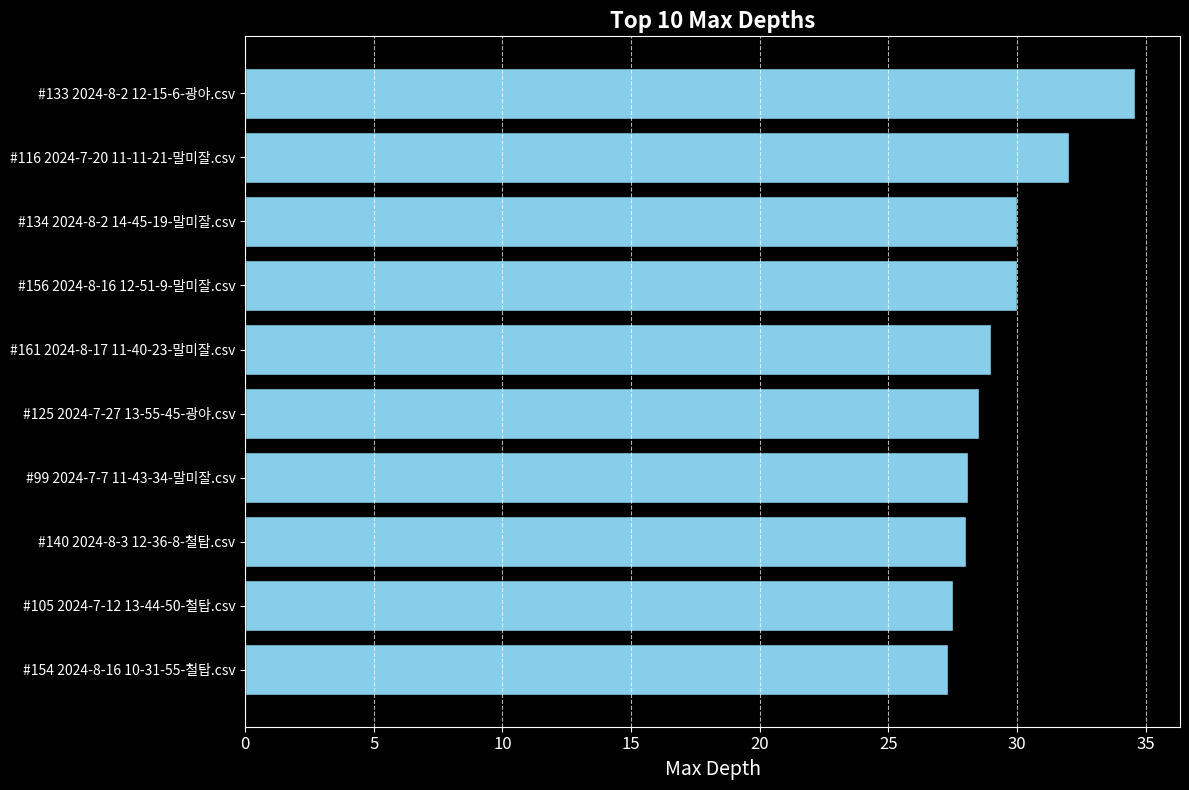

In [110]:
# 시각화 추가
plt.figure(figsize=(12, 8))  # 그래프 크기 조정
plt.barh(top_10_max_depths['Filename'], top_10_max_depths['Max Depth'], color='skyblue', edgecolor='black')
plt.xlabel('Max Depth', fontsize=14)
plt.title('Top 10 Max Depths', fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=10)
plt.gca().invert_yaxis()  # 수평 막대그래프에서 큰 값이 위로 오도록 설정
plt.grid(axis='x', linestyle='--', alpha=0.7)  # 가독성을 위한 그리드 추가
plt.tight_layout()
plt.show()


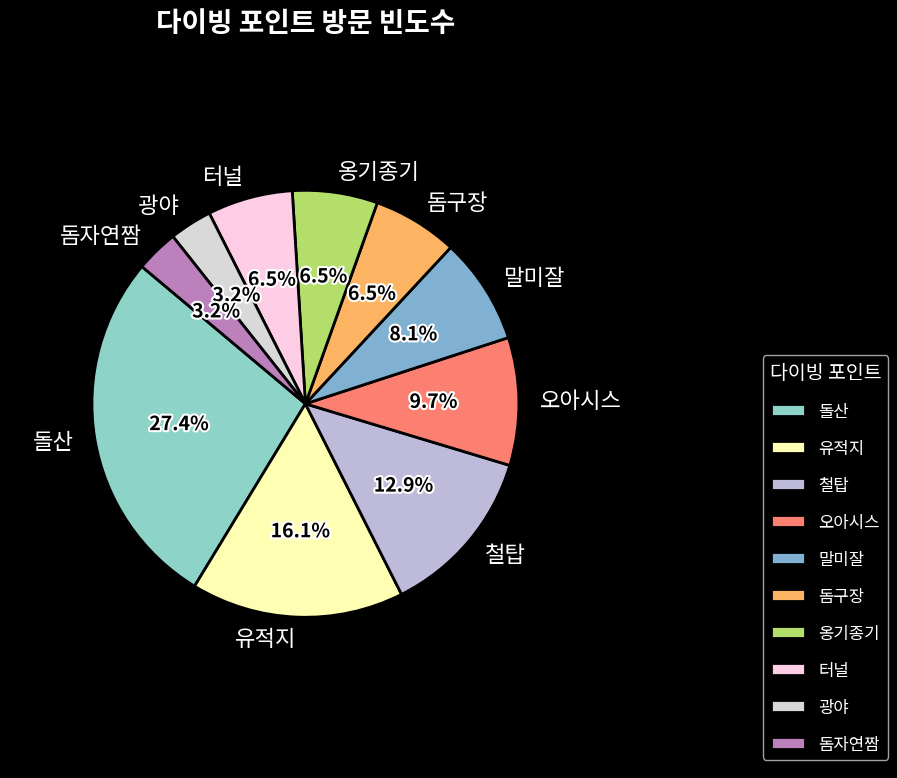

In [111]:
# 각 폴더에 있는 파일 갯수 계산 및 원차트 시각화
folder_file_counts = {k: v for k, v in sorted({folder: len([f for f in os.listdir(os.path.join(base_folder, folder)) if f.endswith('.csv')]) for folder in folders}.items(), key=lambda item: item[1], reverse=True)}

# 원차트 시각화
plt.figure(figsize=(10, 8))
plt.style.use('dark_background')  # 배경을 어둡게 설정하여 프레젠테이션 스타일과 비슷하게 변경

wedges, texts, autotexts = plt.pie(
    folder_file_counts.values(),
    labels=folder_file_counts.keys(),
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Set3.colors,  # 가독성을 위해 컬러 팔레트 변경
    wedgeprops={'edgecolor': 'black', 'linewidth': 2}  # 각 조각의 테두리 추가
)

# 제목 스타일 조정
plt.title('다이빙 포인트 방문 빈도수', fontsize=20, fontweight='bold', loc='center', color='white')
plt.axis('equal')  # 원형 비율을 유지

# 텍스트 안쪽에 넣기 위한 설정 및 선 추가
for text in texts:
    text.set_fontsize(16)
    text.set_color('white')
for autotext in autotexts:
    autotext.set_fontsize(14)
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_path_effects([path_effects.withStroke(linewidth=3, foreground='white')])  # 글자 테두리 추가로 가독성 향상

# 범례 추가
plt.legend(wedges, folder_file_counts.keys(), title="다이빙 포인트", loc="lower right", bbox_to_anchor=(1, 0, 0.5, 1), fontsize=12, title_fontsize=14, labelspacing=1.2)

plt.tight_layout()
plt.show()
